# Recon TAN

In [1]:
from deeptan.graph.model import DeepTAN
from deeptan.utils.uni import get_map_location

/home/wuch/miniforge3/envs/sc/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



    ____                _________    _   __
   / __ \___  ___  ____/_  __/   |  / | / /
  / / / / _ \/ _ \/ __ \/ / / /| | /  |/ / 
 / /_/ /  __/  __/ /_/ / / / ___ |/ /|  /  
/_____/\___/\___/ .___/_/ /_/  |_/_/ |_/   
               /_/                         




In [2]:
model_path="/mnt/hdd2/homext/wuch/xn2p/run/logs/bulk_exp_meth_nmic_g_mincv2.0_minmi0.6_0.72_log1p_ft16/seed_42/DeepTAN_20250321024731_NdCYE_bac/best-model-epoch=0015-val_loss=0.0000.ckpt"
model = DeepTAN.load_from_checkpoint(model_path, map_location=get_map_location())
# Freeze the model
model.eval()
model.freeze()

feature_names = model.all_node_names
print(f"{len(feature_names)} features in the model")
print(feature_names)
del model

13461 features in the model
['1:10260958-10261802', '1:10299652-10300562', '1:10365028-10365970', '1:1049505-1050396', '1:1064003-1064914', '1:1080503-1081383', '1:10810482-10811372', '1:10845933-10846851', '1:10859947-10860885', '1:10876176-10876925', '1:10953053-10953976', '1:1102855-1103765', '1:11215644-11216569', '1:11693310-11694195', '1:11830801-11831754', '1:11965892-11966766', '1:12063940-12064843', '1:12264519-12265438', '1:12429337-12430260', '1:12549787-12550720', '1:12961067-12961875', '1:1312721-1313595', '1:1321527-1322294', '1:1355416-1356334', '1:14305397-14306274', '1:148907-149780', '1:1569306-1570304', '1:15880073-15880990', '1:16137287-16138221', '1:16759240-16760200', '1:16817361-16818210', '1:16896612-16897511', '1:17060678-17061590', '1:17097627-17098519', '1:17286545-17287476', '1:172954-173846', '1:17356074-17356991', '1:1740635-1741495', '1:1744232-1745050', '1:17697064-17698020', '1:17934192-17935148', '1:18038889-18039729', '1:18215207-18216132', '1:1823817

In [3]:
import numpy as np

In [29]:
featfeat_pheno = np.load("/home/wuch/prjs/git_nwafu/DeepTAN/tests/correlation_matrix.npy")
print(featfeat_pheno.shape)
print(featfeat_pheno)
print(f"\nMinimum correlation: {np.nanmin(featfeat_pheno)}")
print(f"Maximum correlation: {np.nanmax(featfeat_pheno)}")
print(f"Mean correlation: {np.nanmean(featfeat_pheno)}")
print(f"Median correlation: {np.nanmedian(featfeat_pheno)}")

(13461, 13461)
[[-0.08473793 -0.11281165 -0.09869179 ... -0.15942056 -0.16265884
  -0.1628066 ]
 [-0.11281165 -0.27763483 -0.14026777 ... -0.13100895 -0.13441671
  -0.13438304]
 [-0.09869179 -0.14026777 -0.09868132 ... -0.1525654  -0.15368345
  -0.15531285]
 ...
 [-0.15942056 -0.13100895 -0.1525654  ... -0.16737697 -0.16764146
  -0.1680674 ]
 [-0.16265884 -0.13441671 -0.15368345 ... -0.16764146 -0.1687504
  -0.16985282]
 [-0.1628066  -0.13438304 -0.15531285 ... -0.1680674  -0.16985282
  -0.16938552]]

Minimum correlation: -1.0789111852645874
Maximum correlation: 0.6141723394393921
Mean correlation: -0.06806556135416031
Median correlation: -0.03705943748354912


In [30]:
# Fill NaN values with 0
featfeat_pheno = np.nan_to_num(featfeat_pheno, nan=0.0)
print(f"\nMinimum correlation: {np.min(featfeat_pheno)}")
print(f"Maximum correlation: {np.max(featfeat_pheno)}")


Minimum correlation: -1.0789111852645874
Maximum correlation: 0.6141723394393921


### Only keep upper triangle of the matrix

In [ ]:
# Create a mask for the upper triangle
# mask = np.triu(np.ones_like(featfeat_pheno, dtype=bool))
# featfeat_pheno = featfeat_pheno[mask]

## Get TOP 100 feature pairs with the highest correlation to phenotype

In [15]:
import polars as pl

In [31]:
sort_ind = np.argsort(featfeat_pheno, axis=None)

In [32]:
top_high_indices = np.unravel_index(sort_ind[-1000:], featfeat_pheno.shape)
top_low_indices = np.unravel_index(sort_ind[:1000], featfeat_pheno.shape)

In [33]:
featnames_top_high = [(feature_names[i], feature_names[j], featfeat_pheno[i, j]) for i, j in zip(top_high_indices[0], top_high_indices[1])]
featnames_top_low = [(feature_names[i], feature_names[j], featfeat_pheno[i, j]) for i, j in zip(top_low_indices[0], top_low_indices[1])]

In [39]:
# Convert to DataFrame and save to CSV
top_high_df = pl.DataFrame(featnames_top_high, schema=["Feature1", "Feature2", "Correlation"]).sort("Correlation", descending=True)
top_low_df = pl.DataFrame(featnames_top_low, schema=["Feature1", "Feature2", "Correlation"]).sort("Correlation", descending=False)
print(top_high_df)
print(top_low_df)

shape: (1_000, 3)
┌─────────────────────┬─────────────────────┬─────────────┐
│ Feature1            ┆ Feature2            ┆ Correlation │
│ ---                 ┆ ---                 ┆ ---         │
│ str                 ┆ str                 ┆ f64         │
╞═════════════════════╪═════════════════════╪═════════════╡
│ AT2G17380           ┆ AT2G39900           ┆ 0.614172    │
│ AT2G39900           ┆ AT2G17380           ┆ 0.614172    │
│ AT2G39900           ┆ 1:26501195-26502039 ┆ 0.501678    │
│ 1:26501195-26502039 ┆ AT2G39900           ┆ 0.501678    │
│ AT2G39900           ┆ AT3G18080           ┆ 0.466674    │
│ …                   ┆ …                   ┆ …           │
│ AT2G22760           ┆ AT2G39900           ┆ 0.167444    │
│ AT1G65720           ┆ AT2G39900           ┆ 0.167438    │
│ AT2G39900           ┆ AT1G65720           ┆ 0.167438    │
│ AT2G39900           ┆ AT4G10100           ┆ 0.167435    │
│ AT4G10100           ┆ AT2G39900           ┆ 0.167435    │
└─────────────────────

/home/wuch/miniforge3/envs/sc/lib/python3.10/functools.py:889: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.
  return dispatch(args[0].__class__)(*args, **kw)


In [45]:
# Deduplicate pairs
top_high_df = top_high_df.unique(subset=["Feature1", "Feature2"])
top_high_df = top_high_df.sort("Correlation", descending=True)
top_low_df = top_low_df.unique(subset=["Feature1", "Feature2"])
top_low_df = top_low_df.sort("Correlation", descending=False)
print(top_high_df)
print(top_low_df)

shape: (1_000, 3)
┌─────────────────────┬─────────────────────┬─────────────┐
│ Feature1            ┆ Feature2            ┆ Correlation │
│ ---                 ┆ ---                 ┆ ---         │
│ str                 ┆ str                 ┆ f64         │
╞═════════════════════╪═════════════════════╪═════════════╡
│ AT2G17380           ┆ AT2G39900           ┆ 0.614172    │
│ AT2G39900           ┆ AT2G17380           ┆ 0.614172    │
│ 1:26501195-26502039 ┆ AT2G39900           ┆ 0.501678    │
│ AT2G39900           ┆ 1:26501195-26502039 ┆ 0.501678    │
│ AT2G39900           ┆ AT3G18080           ┆ 0.466674    │
│ …                   ┆ …                   ┆ …           │
│ AT2G22760           ┆ AT2G39900           ┆ 0.167444    │
│ AT1G65720           ┆ AT2G39900           ┆ 0.167438    │
│ AT2G39900           ┆ AT1G65720           ┆ 0.167438    │
│ AT2G39900           ┆ AT4G10100           ┆ 0.167435    │
│ AT4G10100           ┆ AT2G39900           ┆ 0.167435    │
└─────────────────────

In [24]:
# Save to CSV
top_high_df.write_csv("top_high_correlations.csv")
top_low_df.write_csv("top_low_correlations.csv")

# Plot the correlation matrix

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

<Figure size 640x480 with 0 Axes>

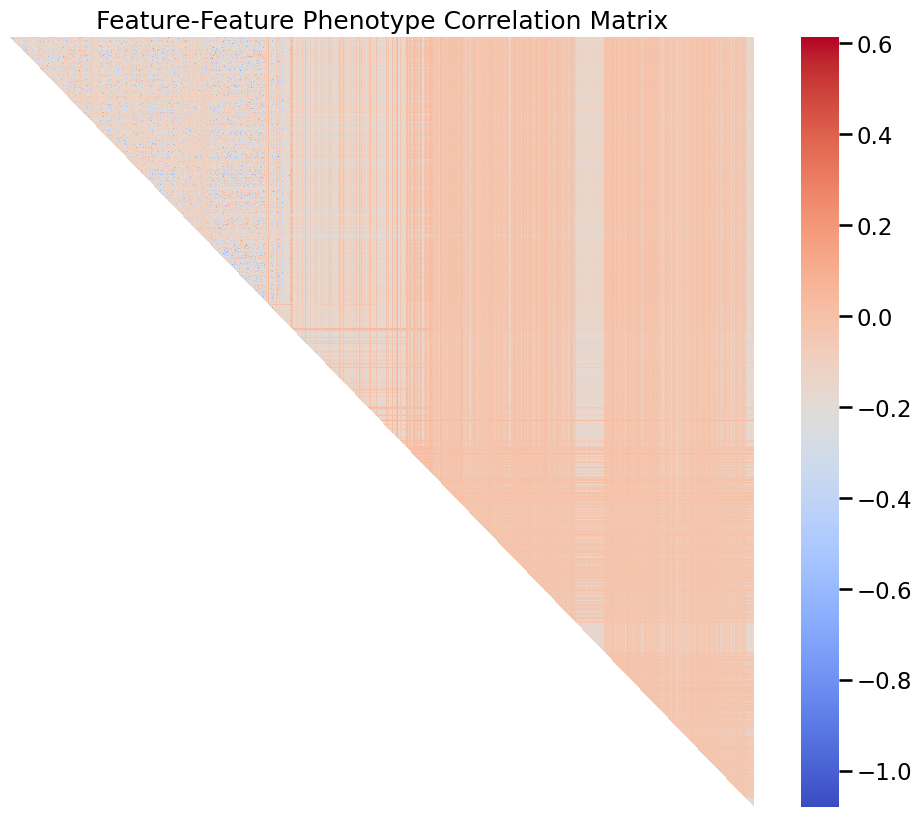

In [14]:
# Try clearing the previous plot if it exists
try:
    plt.clf()
except:
    pass

plt.figure(figsize=(12, 10))
# sns.heatmap(featfeat_pheno, annot=False, fmt=".2f", cmap='coolwarm', xticklabels=feature_names, yticklabels=feature_names)

# Without axis labels for better readability.
# sns.heatmap(featfeat_pheno, annot=False, fmt=".2f", cmap='coolwarm', xticklabels=False, yticklabels=False)

# Clustermap for better visualization of clusters.
# sns.clustermap(featfeat_pheno, cmap='coolwarm')  # , xticklabels=False, yticklabels=False)

# Clustermap with dendrogram, and upper triangle masked, without axis labels.
mask = np.tril(np.ones_like(featfeat_pheno, dtype=bool))
# sns.clustermap(featfeat_pheno, cmap='coolwarm', mask=mask, xticklabels=False, yticklabels=False)  # , dendrogram_ratio=(.1, .2))  # Adjust dendrogram size if needed. Uncomment to use.
# Failed due to the size of the matrix.

sns.heatmap(featfeat_pheno, mask=mask, annot=False, fmt=".2f", cmap='coolwarm', xticklabels=False, yticklabels=False)
plt.title('Feature-Feature Phenotype Correlation Matrix')
plt.show()